# Convolutional Autoencoder

Conv Autoencoder for colorizing pictures of flowers. Encoder part is pre trained VGG16 model without classification layer and decoder part was trained from the ground up. Training set consists of over 4000 photos of flowers and over 3000 pictures created by distorting original images. VGG16 part was frozen during training phase. After training VGG16 weights were unfrozen and model was fine tuned with very small learning rate for another 5 epochs on a different set of images.

Results are underwhelming since model has learned to color flowers with proper colors however tint is very dim and model has issues with colorizing small objects.

TODO: retrain model for more epochs and with regularization <br>
TODO: reimplement (if possible) generator function so it runs faster on Google Colab <br>
TODO: try different approach?

In [152]:
from keras.layers import Conv2D, UpSampling2D, Input
from keras.models import Model
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG16
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
import os
import numpy as np

from skimage import io, color, transform
from sklearn.utils import shuffle
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [439]:
# from IPython.core.display import HTML
# HTML("""
# <style>
# .output_png {
#     display: table-cell;
#     text-align: center;
#     vertical-align: middle;
# }
# </style>
# """)

In [133]:
# path with original photos
flowers_path = 'flowers'

# path to test photos
flowers_test = 'flowers_test'

# path to augmented photos
augmented_path = 'augmented'

# path to photos used in fine tuning 
fine_tune = 'fine_tune'

# required size of the photo
photo_size = 224

In [134]:
# generator used to distort original samples 
generator = ImageDataGenerator(
                featurewise_center=False,
                featurewise_std_normalization=False,
                rotation_range=10,
                width_shift_range=0.1,
                height_shift_range=0.1,
                zoom_range=0.1,
                horizontal_flip=True)

In [135]:
# iterator to save distorted images
iterator = generator.flow_from_directory(
                directory=flowers_path,
                target_size=(photo_size, photo_size),
                class_mode=None,
                save_to_dir=augmented_path,
                save_format='jpg')

Found 4152 images belonging to 5 classes.


In [136]:
def augment_photos(iterator, amount):
    '''
    function used to generate and save dataset
    
    iterator: iterator generating photos
    amount:   used to control how many images to create
    '''
    
    # tqdm to show progress bar
    with tqdm(total=amount) as pbar:
        
        # iterating until desired amount is created
        while amount > 0:
            amount -= 1
            next(iterator)
            pbar.update(1)
        
    # print statistics
    _, _, files = next(os.walk(iterator.save_to_dir))
    print(f'augmented: {len(files)} pictures',)

In [137]:
augment_photos(iterator, 100)


augmented: 3200 pictures


In [39]:
def get_file_names(path):
    '''
    function that returns all jpg files in a given directory
    
    path: path to search for jpg photos
    '''

    # returned array
    photos = []
    
    # iterate over directory
    for dirpath, _, files in os.walk(path):
        for file in files:
            if file.endswith('.jpg'):
                photos.append(os.path.join(dirpath, file))
    return photos

In [3]:
def batch_generator(original_path, augmented_path=None, batch_size=32):
    '''
    function used to yield batches for model while in training phase
    
    original_path:  path to original dataset
    augmented_path: path to distorted dataset
    batch_size:     size of a single batch to yield
    '''
        
    # get all jpg  photos from both paths
    photos = get_file_names(original_path)
    if augmented_path:
        photos += get_file_names(augmented_path)
              
    
    # infinite loop
    while True:
        
        # randomly sample photos for a batch
        indices = np.random.choice(photos, size=batch_size)
        
        # initialize input and output arrays to yield
        x    = np.empty((batch_size, photo_size, photo_size, 3), dtype='float32')
        y    = np.empty((batch_size, photo_size, photo_size, 2), dtype='float32')
        
        # iterate over photos
        for idx, photo in enumerate(indices):
            
            # load photo
            img = io.imread(photo)

            # resize to required size if necessary
            if img.shape != (photo_size, photo_size, 3):
                img = transform.resize(img, (photo_size, photo_size))
            
            # convert to CIE L*a*b color space
            conv = color.rgb2lab(img)
            
            # extract and normalize L channel
            gray = conv[:,:,:1] / 100.0
            
            # resize to shape (photo_size, photo_size, 3)
            gray = np.repeat(gray, 3, axis=-1)
            
            # extract and normalize a* and b* channels
            ab = conv[:,:,1:] / 128.0
            
            # insert channels to proper arrays
            x[idx, :, :, :] = gray
            y[idx, :, :, :] = ab
            
        # rename arrays
        x_data = \
        {
            'enc_input': x
        }
        
        y_data = \
        {
            'dec_output': y
        }
        
        # yield respectively both input and output
        yield (x_data, y_data)

## The Network

In [17]:
# model architecture is based on:
# https://becominghuman.ai/auto-colorization-of-black-and-white-images-using-machine-learning-auto-encoders-technique-a213b47f7339
# download VGG16 model without classification layer
# this part is used as encoder part of the model
vgg = VGG16(include_top=False, input_shape=(photo_size, photo_size, 3))

# freeze model parameters
vgg.trainable = False

# rename input layer
vgg.layers[0]._name = 'enc_input'

In [18]:
# create and connect decoder part of the model
x      = Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same')(vgg.output)
x      = Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same')(x)
x      = UpSampling2D(size=(2,2))(x)
x      = Conv2D(filters=64,  kernel_size=(3,3), strides=(1,1), activation='relu', padding='same')(x)
x      = UpSampling2D(size=(2,2))(x)
x      = Conv2D(filters=32,  kernel_size=(3,3), strides=(1,1), activation='relu', padding='same')(x)
x      = UpSampling2D(size=(2,2))(x)
x      = Conv2D(filters=16,  kernel_size=(3,3), strides=(1,1), activation='relu', padding='same')(x)
x      = UpSampling2D(size=(2,2))(x)
x      = Conv2D(filters=2,   kernel_size=(3,3), strides=(1,1), activation='tanh', padding='same')(x)
out    = UpSampling2D(size=(2,2), name='dec_output')(x)

In [19]:
# build and compile the model
model = Model(vgg.input, out)
model.compile(loss='mse', optimizer='adam')

In [20]:
# callback used to save model after every epoch 
path_checkpoint = 'model_checkpoint.keras'
callback_checkpoint = ModelCheckpoint(filepath=path_checkpoint,
                                      verbose=1,
                                      save_weights_only=True)

In [21]:
# train the model using generator function 
history = model.fit(x=batch_generator(flowers_path, augmented_path=augmented_path),
                    epochs=5,
                    steps_per_epoch=(4152+3200)//16,
                    callbacks=[callback_checkpoint])

Epoch 1/5
459/459 [==============================] - 1609s 4s/step - loss: 0.0367

Epoch 00001: saving model to model_checkpoint.keras
Epoch 2/5
459/459 [==============================] - 1406s 3s/step - loss: 0.0266

Epoch 00002: saving model to model_checkpoint.keras
Epoch 3/5
459/459 [==============================] - 1390s 3s/step - loss: 0.0237

Epoch 00003: saving model to model_checkpoint.keras
Epoch 4/5
459/459 [==============================] - 1390s 3s/step - loss: 0.0218

Epoch 00004: saving model to model_checkpoint.keras
Epoch 5/5
459/459 [==============================] - 1393s 3s/step - loss: 0.0210

Epoch 00005: saving model to model_checkpoint.keras


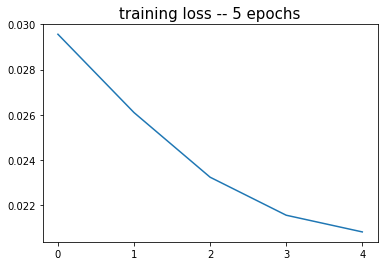

In [38]:
# plot training loss 
plt.figure().gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.plot(history.history['loss'])
plt.title('training loss -- 5 epochs', fontsize=15)
plt.show()

# training could be done for more epochs 
# since training loss is starting to flatten 

c:\users\msi\appdata\local\programs\python\python36\lib\site-packages\skimage\color\colorconv.py:1128: UserWarning: Color data out of range: Z < 0 in 391 pixels
  return xyz2rgb(lab2xyz(lab, illuminant, observer))


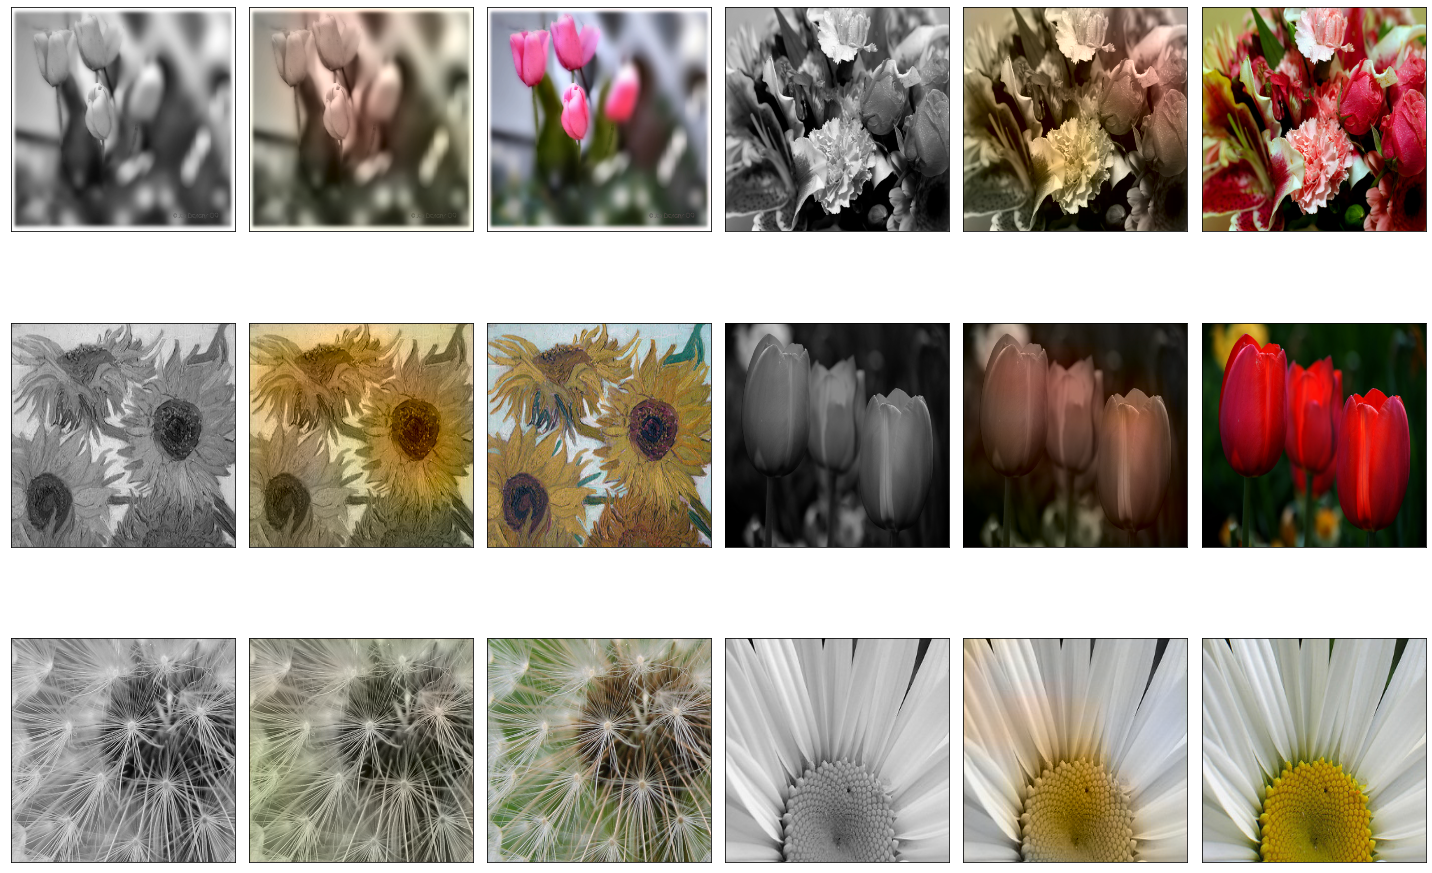

In [155]:
def plot_example_results(path):
    '''
    function used to plot example results of the network
    respectively: input image, colored image, original image 
    
    path: path to test dataset
    '''
    
    # list all photos and choose randomly 6 
    photos = get_file_names(path)
    indices = np.random.choice(photos, size=6)
    
    # instantiate array for Autoencoder
    x    = np.empty((6, photo_size, photo_size, 3), dtype='float32')
    y    = np.empty((6, photo_size, photo_size, 2), dtype='float32')
    
    # array with original photos
    imgs = np.empty((6, photo_size, photo_size, 3), dtype='float32')
    
    for idx, photo in enumerate(indices):
        
        img = io.imread(photo)
        
        if img.shape != (photo_size, photo_size, 3):
            img = transform.resize(img, (photo_size, photo_size))
            
        imgs[idx, :, :, :] = img
        
        conv = color.rgb2lab(img)
        gray = conv[:,:,:1] / 100.0
        gray = np.repeat(gray, 3, axis=-1)
        ab = conv[:,:,1:] / 128.0
        
        x[idx, :, :, :] = gray
        y[idx, :, :, :] = ab
        
    x_data = \
    {
        'enc_input': x
    }
        
    # get model predictions
    preds = model.predict(x_data)
    
    # concatenate L, a* and b* channels
    conc = np.concatenate((x[:,:,:,:1]*100, preds*128), axis=-1)
    
    # convert back to RGB colorspace
    colored = color.lab2rgb(conc)

    # 3 by 6 grid for photos
    fig, axs = plt.subplots(3, 6, figsize=(20,20))

    # iterate over axs
    for i in range(3):
        for j in range(0, 4, 3):
            
            # show photos
            axs[i, j].imshow(x[i+j])
            axs[i, j+1].imshow(colored[i+j])
            axs[i, j+2].imshow(imgs[i+j])
            
            # turn off x and y ticks
            axs[i, j].get_yaxis().set_visible(False)
            axs[i, j].get_xaxis().set_visible(False)
            
            axs[i, j+1].get_yaxis().set_visible(False)
            axs[i, j+1].get_xaxis().set_visible(False)
            
            axs[i, j+2].get_yaxis().set_visible(False)
            axs[i, j+2].get_xaxis().set_visible(False)
            
            fig.tight_layout()
    fig.tight_layout()
    
    
plot_example_results(flowers_test)

## Fine Tuning (ish)

In [161]:
# unfreeze model weights from 4th and 5th conv blocks
for layer in model.layers[11:19]:
    layer.trainable = True

In [162]:
# print whether layer is frozen or not
for layer in model.layers:
    print(layer.name, '\t', layer.trainable)

enc_input 	 True
block1_conv1 	 False
block1_conv2 	 False
block1_pool 	 False
block2_conv1 	 False
block2_conv2 	 False
block2_pool 	 False
block3_conv1 	 False
block3_conv2 	 False
block3_conv3 	 False
block3_pool 	 False
block4_conv1 	 True
block4_conv2 	 True
block4_conv3 	 True
block4_pool 	 True
block5_conv1 	 True
block5_conv2 	 True
block5_conv3 	 True
block5_pool 	 True
conv2d_12 	 True
conv2d_13 	 True
up_sampling2d_8 	 True
conv2d_14 	 True
up_sampling2d_9 	 True
conv2d_15 	 True
up_sampling2d_10 	 True
conv2d_16 	 True
up_sampling2d_11 	 True
conv2d_17 	 True
dec_output 	 True


In [163]:
# in order not to destroy learned VGG16 weights 
# chose learning rate to be really small
opt = Adam(lr=1e-7)

# recompile the model
model.compile(loss='mse', optimizer=opt)

In [164]:
# saving model after every epoch
path_checkpoint = 'model_checkpoint_fine.keras'
callback_checkpoint = ModelCheckpoint(filepath=path_checkpoint,
                                      verbose=1,
                                      save_weights_only=True)

In [165]:
# refit the model with new dataset
fine_history = model.fit(x=batch_generator(fine_tune),
                         epochs=5,
                         steps_per_epoch=3200/16,
                         callbacks=[callback_checkpoint])

Epoch 1/5
200/200 [==============================] - 1845s 9s/step - loss: 0.0207

Epoch 00001: saving model to model_checkpoint_fine.keras
Epoch 2/5
200/200 [==============================] - 1374s 7s/step - loss: 0.0209

Epoch 00002: saving model to model_checkpoint_fine.keras
Epoch 3/5
200/200 [==============================] - 1318s 7s/step - loss: 0.0203

Epoch 00003: saving model to model_checkpoint_fine.keras
Epoch 4/5
200/200 [==============================] - 1287s 6s/step - loss: 0.0205

Epoch 00004: saving model to model_checkpoint_fine.keras
Epoch 5/5
200/200 [==============================] - 1287s 6s/step - loss: 0.0203

Epoch 00005: saving model to model_checkpoint_fine.keras


c:\users\msi\appdata\local\programs\python\python36\lib\site-packages\skimage\color\colorconv.py:1128: UserWarning: Color data out of range: Z < 0 in 380 pixels
  return xyz2rgb(lab2xyz(lab, illuminant, observer))


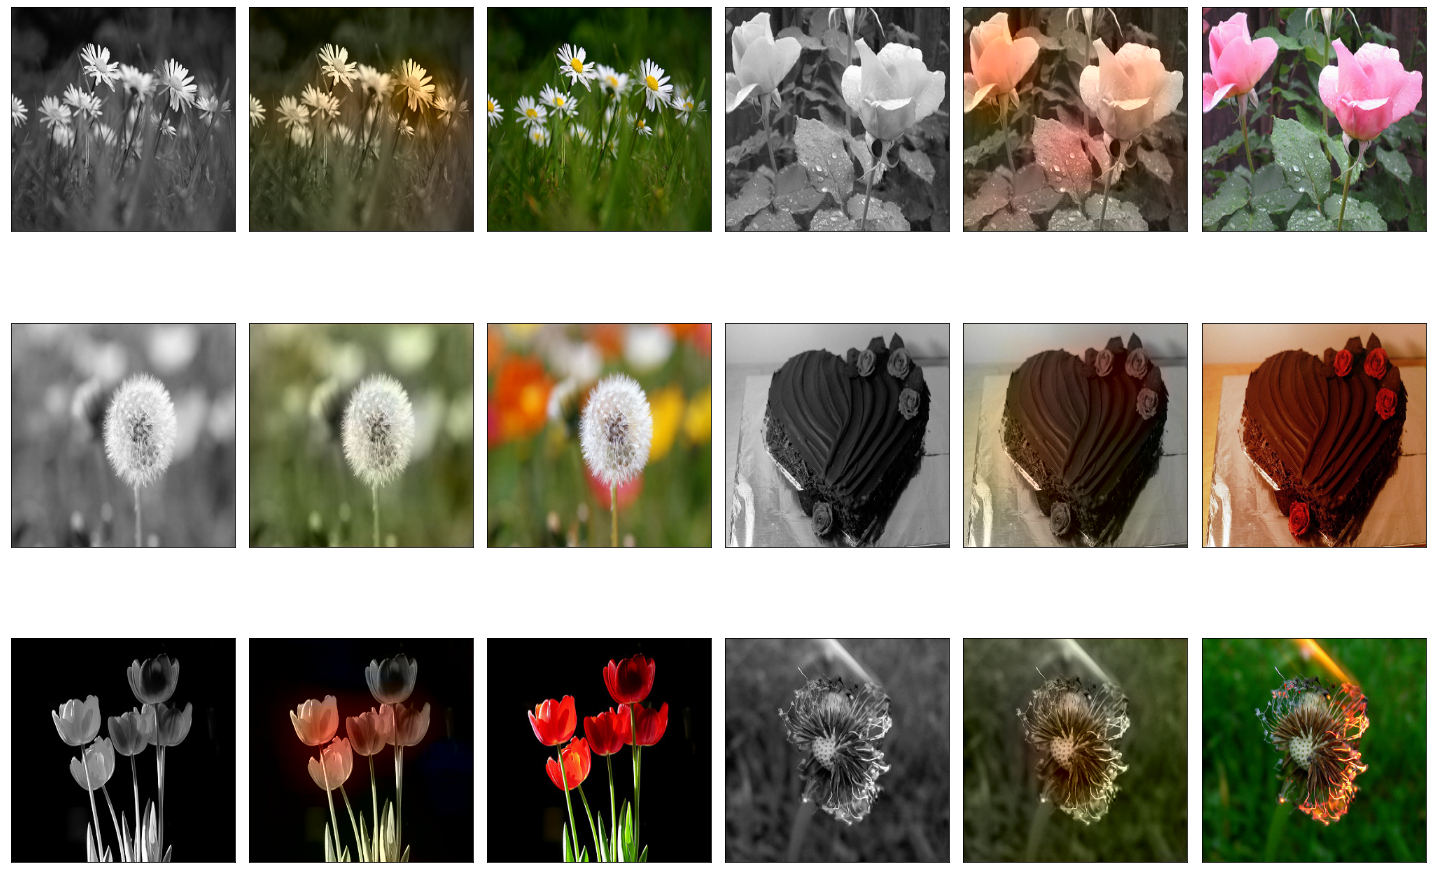

In [166]:
# plot example results after fine tuning
plot_example_results(flowers_test)

In [172]:
res = model.evaluate(batch_generator(flowers_test), batch_size=16, steps=177/16)

11/11 [==============================] - 36s 3s/step - loss: 0.0249


In [174]:
print('model loss on test set: ', res)

model loss on test set:  0.02494879998266697
